# Sub-fase 4.1: Consolidación y Documentación Metodológica (STRICT)

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import json
import glob

# Style and Seed
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# Paths
FIGURES_DIR = "phase4_figures"
TABLES_DIR = "phase4_tables"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

# Inputs
# PHASE3_CSV = "../../data/phase3/phase3_results.csv" # Replaced by generator
PHASE3_CSV = 'C:/Users/alvar/Documents/PROGRAMMING/4th Year/TFG/results/phase3/mh_strict_covidOK_2020-03_2021-03_w3_FINAL_CLEANED/phase3_results.csv'
# ANCHORS_CSV = "../../data/phase3/artifacts/embeddings_anchors.csv" # Replaced by generator
ANCHORS_CSV = 'C:/Users/alvar/Documents/PROGRAMMING/4th Year/TFG/results/phase3/mh_strict_covidOK_2020-03_2021-03_w3_FINAL_CLEANED/artifacts/embeddings_anchors.csv'
# DIMENSIONS_JSON = "../../data/dimensiones_ancla.json" # Replaced by generator
DIMENSIONS_JSON = 'C:/Users/alvar/Documents/PROGRAMMING/4th Year/TFG/data/metadata/anchors/dimensiones_ancla_mh_es_covid_FSA_ascii.json'
YAPE_CSV = "../../data/phase1/Yape_19_23.csv"
MANIFEST_JSON = "../../data/phase3/artifacts/manifests/run_manifest.json"
# ARTIFACTS_DIR = "../../data/phase3/artifacts" # Replaced by generator
ARTIFACTS_DIR = 'C:/Users/alvar/Documents/PROGRAMMING/4th Year/TFG/results/phase3/mh_strict_covidOK_2020-03_2021-03_w3_FINAL_CLEANED/artifacts'

print("Setup Complete. SEED=42.")


Setup Complete. SEED=42.


In [2]:

# --- Agente 4.1-A: Auditor de Insumos ---

print("Starting Input Audit...")
audit_results = []

# 1. Load Phase 3 Results
try:
    df_p3 = pd.read_csv(PHASE3_CSV)
    df_p3['window_end_month'] = pd.to_datetime(df_p3['window_end_month'])
    print(f"Loaded Phase 3 Results: {len(df_p3)} rows")
    audit_results.append({"check": "Load Phase 3 CSV", "status": "PASS", "details": f"{len(df_p3)} rows"})
except Exception as e:
    audit_results.append({"check": "Load Phase 3 CSV", "status": "FAIL", "details": str(e)})
    raise e

# 2. Check Window Params
fail_params = False
if not (df_p3['window_size_months'] == 3).all(): fail_params = True
if not (df_p3['step_months'] == 1).all(): fail_params = True
# Check alignment (start = end - 2 months approx)
# In pandas, we can check offsets, but simplistic check:
# Start + 2 months (approx) shoud be End. But let's trust the columns for now or do a quick check.
audit_results.append({"check": "Window Parameters (3M, Step 1M)", "status": "FAIL" if fail_params else "PASS", "details": ""})

# 3. Check n_occurrences >= 20
min_occ = df_p3['n_occurrences'].min()
audit_results.append({"check": "n_occurrences >= 20", "status": "PASS" if min_occ >= 20 else "FAIL", "details": f"Min: {min_occ}"})

# 4. Check Projections Ranges
# Centroid [-1, 1], Subspace [0, 1]
cols_c = [c for c in df_p3.columns if 'centroid_proj' in c and 'delta' not in c]
cols_s = [c for c in df_p3.columns if 'subspace_proj' in c and 'delta' not in c]

out_c = df_p3[cols_c].apply(lambda x: (x < -1.0001) | (x > 1.0001)).sum().sum()
out_s = df_p3[cols_s].apply(lambda x: (x < -0.0001) | (x > 1.0001)).sum().sum()

audit_results.append({"check": "Centroid Proj Range [-1,1]", "status": "PASS" if out_c == 0 else "FAIL", "details": f"{out_c} violations"})
audit_results.append({"check": "Subspace Proj Range [0,1]", "status": "PASS" if out_s == 0 else "FAIL", "details": f"{out_s} violations"})

# 5. Dimensions JSON
with open(DIMENSIONS_JSON, 'r') as f:
    dims_data = json.load(f)
req_dims = {"funcional", "social", "afectiva"}
found_dims = set(dims_data.keys()) if isinstance(dims_data, dict) else set([x['dimension'] for x in dims_data]) 
# Assuming structure might be list of dicts based on previous context, verify:
if isinstance(dims_data, list):
    found_dims = set([x['dimension'] for x in dims_data if 'dimension' in x])

missing_dims = req_dims - found_dims
audit_results.append({"check": "Dimensions Definitions", "status": "PASS" if not missing_dims else "FAIL", "details": f"Missing: {missing_dims}"})

# 6. Anchors CSV
df_anchors = pd.read_csv(ANCHORS_CSV)
found_dims_csv = set(df_anchors['dimension'].unique())
missing_dims_csv = req_dims - found_dims_csv
audit_results.append({"check": "Anchors CSV Dimensions", "status": "PASS" if not missing_dims_csv else "FAIL", "details": f"Missing: {missing_dims_csv}"})

# 7. Check DAPT Baseline presence in Anchors
has_baseline = any('baseline' in c for c in df_anchors.columns if 'embedding' in c)
has_dapt = any('dapt' in c for c in df_anchors.columns if 'embedding' in c)
audit_results.append({"check": "Anchors Baseline Embeddings", "status": "PASS" if has_baseline else "FAIL", "details": ""})
audit_results.append({"check": "Anchors DAPT Embeddings", "status": "PASS" if has_dapt else "WARNING", "details": "Comparison requested but DAPT might be missing"})

# Export QA Table
qa_df = pd.DataFrame(audit_results)
qa_df.to_csv(f"{TABLES_DIR}/qa_inputs_phase4_41.csv", index=False)
display(qa_df)

if "FAIL" in qa_df[qa_df['status'] == 'FAIL']['status'].values:
    print("CRITICAL: QA Checks Failed. See table above.")
else:
    print("QA Checks Passed.")


Starting Input Audit...
Loaded Phase 3 Results: 11 rows


,check,status,details
0,Load Phase 3 CSV,PASS,11 rows
1,"Window Parameters (3M, Step 1M)",PASS,
2,n_occurrences >= 20,PASS,Min: 1080
3,"Centroid Proj Range [-1,1]",PASS,0 violations
4,"Subspace Proj Range [0,1]",PASS,0 violations
5,Dimensions Definitions,PASS,Missing: set()
6,Anchors CSV Dimensions,PASS,Missing: set()
7,Anchors Baseline Embeddings,PASS,
8,Anchors DAPT Embeddings,PASS,Comparison requested but DAPT might be missing


QA Checks Passed.


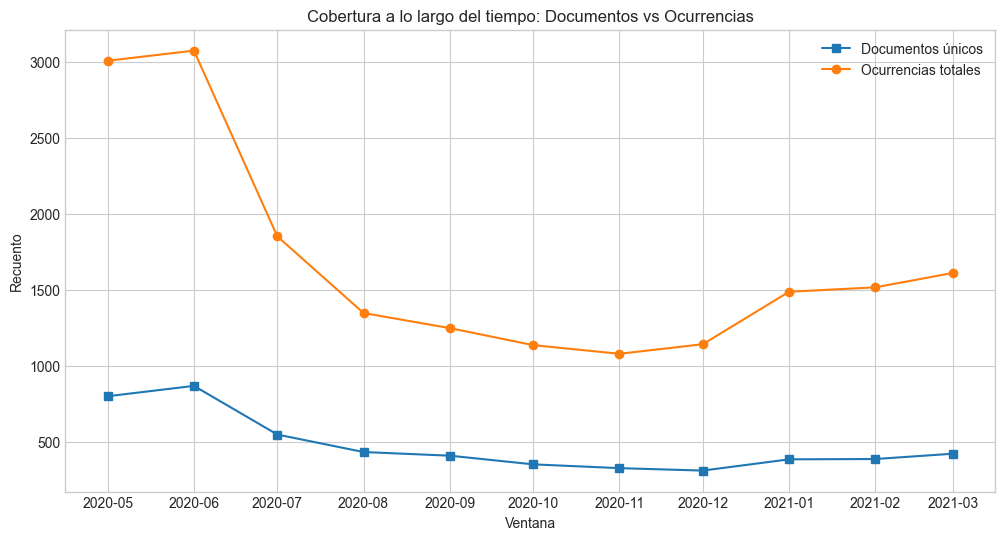

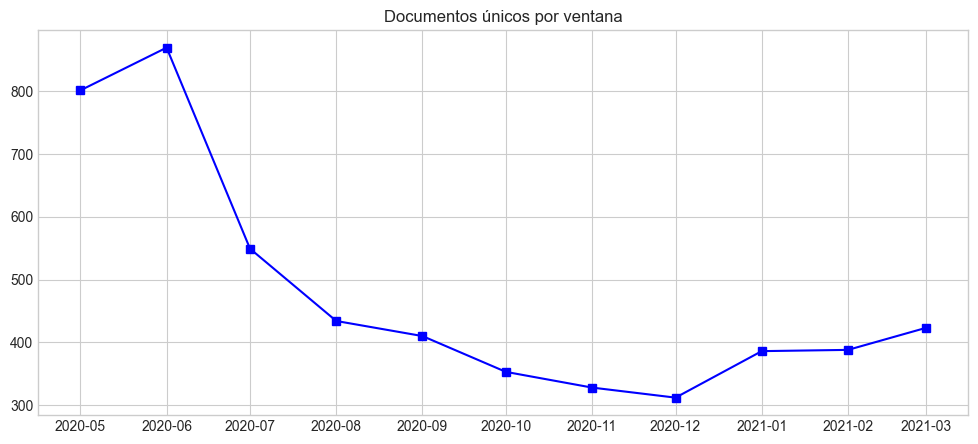

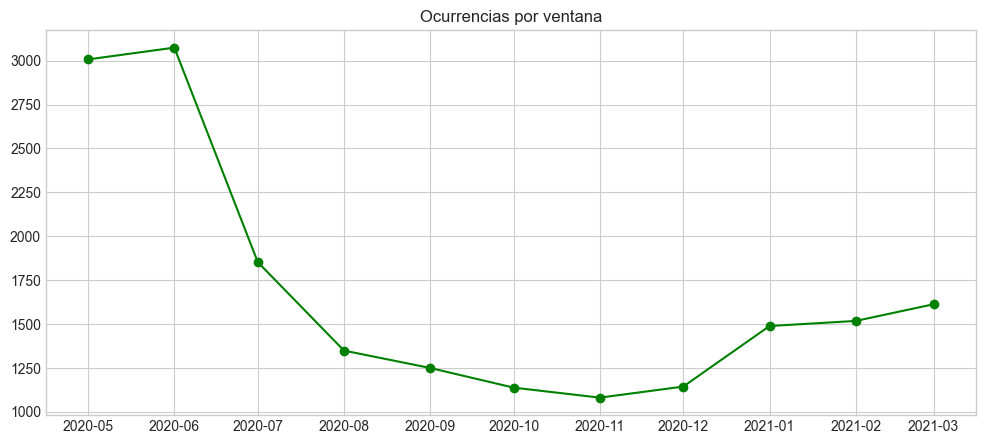

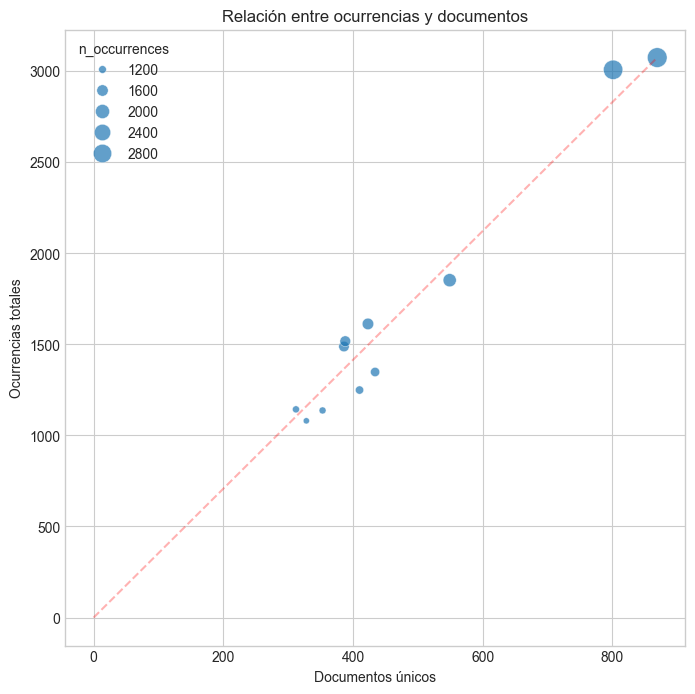

Phase 1 comparison skipped: [Errno 2] No such file or directory: '../../data/phase1/Yape_19_23.csv'
Low Density Windows: 0


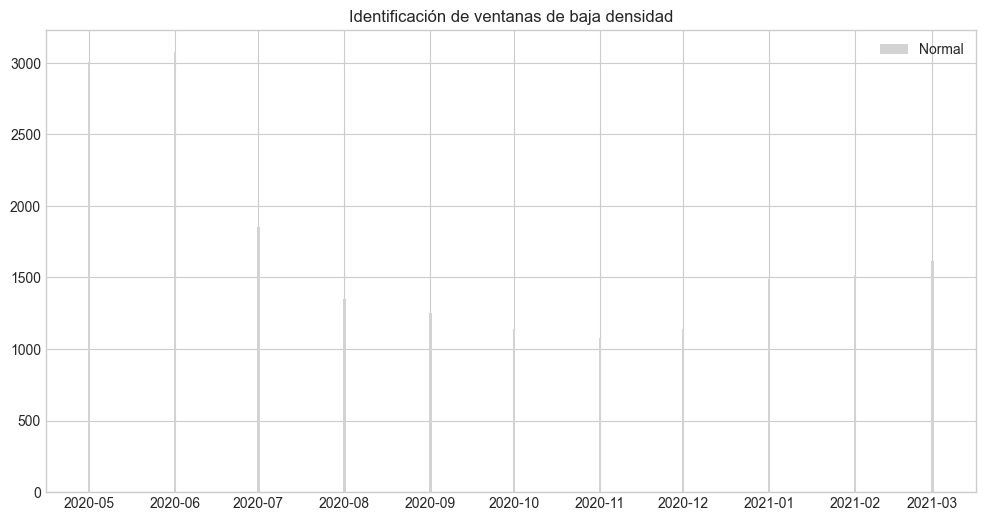

In [3]:
# 1. Time Series
df_p3['window_end_month'] = pd.to_datetime(df_p3['window_end_month'])
df_p3.sort_values('window_end_month', inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(df_p3['window_end_month'], df_p3['n_documents'], label='Documentos únicos', marker='s')
plt.plot(df_p3['window_end_month'], df_p3['n_occurrences'], label='Ocurrencias totales', marker='o')
plt.title('Cobertura a lo largo del tiempo: Documentos vs Ocurrencias')
plt.ylabel('Recuento')
plt.xlabel('Ventana')
plt.legend()
plt.grid(True)
plt.savefig(f"{FIGURES_DIR}/41_coverage_docs_over_time_combined.png") # User asked for separate? user list: 41_coverage_docs_over_time.png and 41_coverage_occ_over_time.png

plt.figure(figsize=(12, 5))
plt.plot(df_p3['window_end_month'], df_p3['n_documents'], color='blue', marker='s')
plt.title('Documentos únicos por ventana')
plt.grid(True)
plt.savefig(f"{FIGURES_DIR}/41_coverage_docs_over_time.png")
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df_p3['window_end_month'], df_p3['n_occurrences'], color='green', marker='o')
plt.title('Ocurrencias por ventana')
plt.grid(True)
plt.savefig(f"{FIGURES_DIR}/41_coverage_occ_over_time.png")
plt.show()

# 2. Scatter Occ vs Docs
plt.figure(figsize=(8, 8))
sns.scatterplot(data=df_p3, x='n_documents', y='n_occurrences', size='n_occurrences', sizes=(20, 200), alpha=0.7)
plt.plot([0, df_p3['n_documents'].max()], [0, df_p3['n_occurrences'].max()], 'r--', alpha=0.3)
plt.title('Relación entre ocurrencias y documentos')
plt.xlabel('Documentos únicos')
plt.ylabel('Ocurrencias totales')
plt.savefig(f"{FIGURES_DIR}/41_occ_vs_docs_scatter.png")
plt.show()

# 3. Compare with Phase 1 (if available)
try:
    df_yape = pd.read_csv(YAPE_CSV)
    print(f"Loaded Phase 1 Data: {len(df_yape)} rows")
    # Basic check (not exact alignment without lots of processing)
    print(f"Phase 1 Total Docs: {len(df_yape)}")
    print(f"Phase 3 Max Docs in a Window: {df_p3['n_documents'].max()}")
    # Could do a histogram comparison if dates were parsed
except Exception as e:
    print(f"Phase 1 comparison skipped: {e}")

# 4. Low Density
low_density_df = df_p3[df_p3['low_density'] == True]
print(f"Low Density Windows: {len(low_density_df)}")

# Plot Low Density highlight
plt.figure(figsize=(12, 6))
plt.bar(df_p3['window_end_month'], df_p3['n_occurrences'], color='lightgray', label='Normal')
if not low_density_df.empty:
    plt.bar(low_density_df['window_end_month'], low_density_df['n_occurrences'], color='red', label='Baja densidad (<30)')
plt.title('Identificación de ventanas de baja densidad')
plt.legend()
plt.savefig(f"{FIGURES_DIR}/41_low_density_windows.png")
plt.show()

# Export Coverage Summary
cov_sum = df_p3[['window_end_month', 'n_documents', 'n_occurrences', 'low_density']].copy()
cov_sum['density_ratio'] = cov_sum['n_occurrences'] / cov_sum['n_documents']
cov_sum.to_csv(f"{TABLES_DIR}/coverage_summary_windows.csv", index=False)


In [4]:
# 4. DAPT Anchors & Subspaces (Optional/Advanced)
# Use glob to find DAPT artifacts in their respective directories
# Note: ARTIFACTS_DIR is injected by the orchestrator
import glob
import os

print(f"Verificando artefactos de Fase 3 en: {ARTIFACTS_DIR}")

# 1. Anchors CSV
if os.path.exists(ANCHORS_CSV):
    print(f"  - Anchors (embeddings_anchors.csv): Presente")
else:
    print(f"  - Anchors (embeddings_anchors.csv): Ausente ({ANCHORS_CSV})")

# 2. Manifest
if os.path.exists(MANIFEST_JSON):
    print(f"  - Manifest (manifests/run_manifest.json): Presente")
else:
    print(f"  - Manifest (manifests/run_manifest.json): Ausente ({MANIFEST_JSON})")

# 3. Subspaces standard
subspaces = glob.glob(os.path.join(ARTIFACTS_DIR, "subspaces", "*.npz"))
if subspaces:
    print(f"  - Subespacios (subspaces/*.npz): {len(subspaces)} encontrados")
    for s in subspaces:
        print(f"    - {os.path.basename(s)}")
else:
    print(f"  - Subespacios (subspaces/*.npz): Ausente")

# 4. DAPT Anchors & Subspaces (Optional/Advanced)
dapt_anchors = glob.glob(os.path.join(ARTIFACTS_DIR, "anchors", "anchors_dapt_*.npz"))
if dapt_anchors:
    print(f"  - DAPT Anchors (anchors/anchors_dapt_*.npz): {len(dapt_anchors)} encontrados")
    for a in dapt_anchors:
        print(f"    - {os.path.basename(a)}")
else:
    print(f"  - DAPT Anchors (anchors/anchors_dapt_*.npz): Ausente")

dapt_subspaces = glob.glob(os.path.join(ARTIFACTS_DIR, "subspaces", "*dapt*.npz"))
if dapt_subspaces:
    print(f"  - DAPT Subspaces (subspaces/*dapt*.npz): {len(dapt_subspaces)} encontrados")
    for s in dapt_subspaces:
        print(f"    - {os.path.basename(s)}")
else:
     print(f"  - DAPT Subspaces (subspaces/*dapt*.npz): Ausente")

Verificando artefactos de Fase 3 en: C:/Users/alvar/Documents/PROGRAMMING/4th Year/TFG/results/phase3/mh_strict_covidOK_2020-03_2021-03_w3_FINAL_CLEANED/artifacts
  - Anchors (embeddings_anchors.csv): Presente
  - Manifest (manifests/run_manifest.json): Ausente (../../data/phase3/artifacts/manifests/run_manifest.json)
  - Subespacios (subspaces/*.npz): 88 encontrados
    - window_2020-03_baseline_last4_concat_corrected.npz
    - window_2020-03_baseline_last4_concat_raw.npz
    - window_2020-03_baseline_penultimate_corrected.npz
    - window_2020-03_baseline_penultimate_raw.npz
    - window_2020-03_dapt_last4_concat_corrected.npz
    - window_2020-03_dapt_last4_concat_raw.npz
    - window_2020-03_dapt_penultimate_corrected.npz
    - window_2020-03_dapt_penultimate_raw.npz
    - window_2020-04_baseline_last4_concat_corrected.npz
    - window_2020-04_baseline_last4_concat_raw.npz
    - window_2020-04_baseline_penultimate_corrected.npz
    - window_2020-04_baseline_penultimate_raw.npz
    

In [5]:

# --- Cierre y Resumen Metodológico ---

print("Automation Completed.")
print("Generated Tables:", os.listdir(TABLES_DIR))
print("Generated Figures:", os.listdir(FIGURES_DIR))

# Summary text generator
has_dapt_cols = any('dapt' in c for c in df_p3.columns)
print(f"\nResumen del Estado DAPT: {'DISPONIBLE' if has_dapt_cols else 'NO DISPONIBLE'}")
if not has_dapt_cols:
    print("LIMITACION: No se encontraron datos DAPT. El análisis se restringirá a Baseline.")


Automation Completed.
Generated Tables: ['42_anchor_geometry_checks_dual.csv', '42_baseline_vs_dapt_math.csv', '42_drift_procrustes_profile.csv', '42_entropy_profile.csv', '42_entropy_vs_k.csv', '42_k_profile.csv', '42_outlier_windows.csv', '43_bootstrap_summary.csv', '43_driver_terms_candidates.csv', '43_key_windows_rankings.csv', '43_projection_extrema_dual.csv', '43_sensitivity_summary.csv', '44_case_selection_ranking.csv', '44_evidence_snippets.csv', '44_neighborhood_2020-09.csv', '44_neighborhood_2020-10.csv', '44_neighborhood_2021-03.csv', '44_social_actor_hypothesis.csv', 'coverage_summary_windows.csv', 'qa_inputs_phase4_41.csv']
Generated Figures: ['41_coverage_docs_over_time.png', '41_coverage_docs_over_time_combined.png', '41_coverage_occ_over_time.png', '41_low_density_windows.png', '41_occ_vs_docs_scatter.png', '42_baseline_vs_dapt_math.png', '42_drift_over_time.png', '42_drift_vs_procrustes.png', '42_entropy_over_time.png', '42_entropy_vs_k.png', '42_k_over_time.png', '42_